In [51]:
import pandas as pd
import matplotlib.pyplot as plt
# from sklearn.feature_extraction.text import TfidfVectorizer

metadata = pd.read_json("C:/Ironhack/W6/ReviewSense/datasets/meta_All_Beauty.jsonl", lines=True)


In [52]:
missing_counts = metadata.isna().sum()
print(missing_counts)
print(metadata.shape)
print(metadata.head())
print(metadata.columns)


main_category           0
title                   0
average_rating          0
rating_number           0
features                0
description             0
price               94886
images                  0
videos                  0
store               11331
categories              0
details                 0
parent_asin             0
bought_together    112590
dtype: int64
(112590, 14)
  main_category                                              title  \
0    All Beauty  Howard LC0008 Leather Conditioner, 8-Ounce (4-...   
1    All Beauty  Yes to Tomatoes Detoxifying Charcoal Cleanser ...   
2    All Beauty   Eye Patch Black Adult with Tie Band (6 Per Pack)   
3    All Beauty  Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...   
4    All Beauty  Precision Plunger Bars for Cartridge Grips – 9...   

   average_rating  rating_number  \
0             4.8             10   
1             4.5              3   
2             4.4             26   
3             3.1            102   
4        

In [87]:
asin_check = metadata.groupby('title')['parent_asin'].nunique().sort_values(ascending=False)

# Filter for titles that have more than 1 ASIN
conflicts = asin_check[asin_check > 1]
print(f"Number of titles with multiple ASINs: {len(conflicts)}")
print(conflicts.head())

Number of titles with multiple ASINs: 1445
title
BFWood                                                                                    18
EKLOEN 12PCS/9PCS/6PCS Multifunctional Headband Magic Mask Scarf                          16
Eyelash Growth Serum                                                                      15
                                                                                          12
BRISON Silicone Bra Inserts Breast Pads Gel Cup Padding Swimsuit +Racerback Strap Clip    12
Name: parent_asin, dtype: int64


In [53]:
import pandas as pd

# 1. Using .unique() - returns an array
unique_array = metadata['title'].unique()
# 2. Using .nunique() - returns the count
unique_count = metadata['title'].nunique()

# 3. Using value_counts() - shows unique names + their frequency
unique_counts = metadata['title'].value_counts()

print(f"Unique Names Array: {unique_array}")
print(f"Total Unique Count: {unique_count}")
print("\nTop Unique Products and Counts:")
print(unique_counts)

Unique Names Array: ['Howard LC0008 Leather Conditioner, 8-Ounce (4-Pack)'
 'Yes to Tomatoes Detoxifying Charcoal Cleanser (Pack of 2) with Charcoal Powder, Tomato Fruit Extract, and Gingko Biloba Leaf Extract, 5 fl. oz.'
 'Eye Patch Black Adult with Tie Band (6 Per Pack)' ...
 '[10Pack] Makeup Brushes Set Cosmetics Tools Kit Peacock Style - Premium Professional Beauty Face Eye Shadow Concealer Blending Brush - Gradient Fantasy Handles For Gift (Pink)'
 'Xcoser Pretty Party Anna Wig Hair Tails Hair Style for Cosplay Accessories'
 "DVIO Men's Voyage Perfume, Spicy woody fragrance, Long Lasting Perfume, Men's Special Perfume, 100ML"]
Total Unique Count: 110566

Top Unique Products and Counts:
title
BFWood                                                                                                                                                                                                      18
EKLOEN 12PCS/9PCS/6PCS Multifunctional Headband Magic Mask Scarf                       

In [54]:
missing_counts = metadata.isna().sum()
print(missing_counts)

main_category           0
title                   0
average_rating          0
rating_number           0
features                0
description             0
price               94886
images                  0
videos                  0
store               11331
categories              0
details                 0
parent_asin             0
bought_together    112590
dtype: int64


In [ ]:
metadata_unique = metadata.drop_duplicates(subset=['title']).copy()

metadata_unique['main_category'] = metadata_unique['main_category'].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
metadata_unique['title'] = metadata_unique['title'].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
metadata_unique['description'] = metadata_unique['description'].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
metadata_unique['combined_text'] =metadata_unique['title']

In [56]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
model = SentenceTransformer('distilbert-base-nli-stsb-mean-tokens')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

In [57]:
embeddings = model.encode(
    metadata_unique['combined_text'].tolist(),
    show_progress_bar=True,
    normalize_embeddings=True
    )

Batches:   0%|          | 0/3456 [00:00<?, ?it/s]

In [103]:
import numpy as np
np.save('product_embeddings_v1.npy', embeddings)

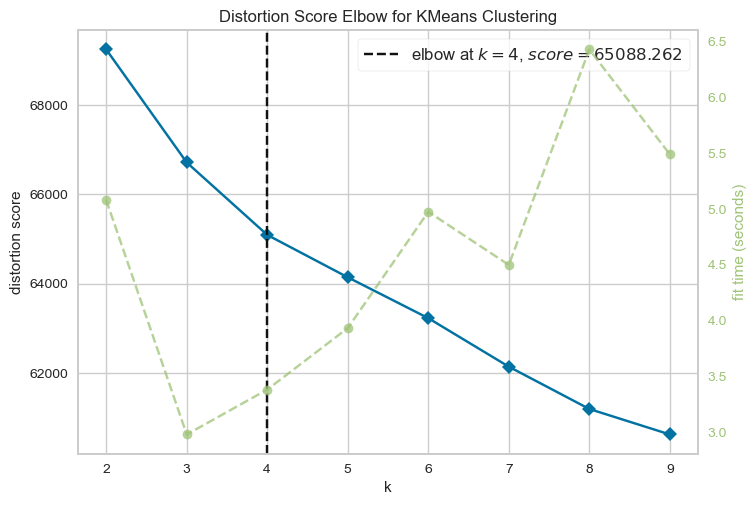

4


In [84]:
from sklearn.cluster import KMeans
# !pip install yellowbrick
# Your code here:
from yellowbrick.cluster import KElbowVisualizer

kmeans = KMeans(random_state=42)
visualizer = KElbowVisualizer(kmeans, k=(2,10))
visualizer.fit(embeddings)
visualizer.show()
optimal_k = visualizer.elbow_value_
print(optimal_k)

In [ ]:
kmeans_4 = KMeans(n_clusters=optimal_k, random_state=42).fit(embeddings)

labels = kmeans_4.predict(embeddings)

clusters = kmeans_4.labels_.tolist()

In [60]:
print((clusters.count(0), clusters.count(1), clusters.count(2), clusters.count(3)))
print(clusters)

(23326, 27010, 28346, 31884)
[0, 2, 0, 1, 0, 1, 0, 1, 0, 3, 1, 1, 0, 2, 0, 0, 0, 2, 3, 3, 2, 2, 2, 3, 3, 3, 1, 1, 3, 1, 1, 0, 2, 0, 0, 2, 1, 2, 0, 1, 0, 2, 2, 1, 2, 2, 1, 2, 3, 2, 2, 1, 0, 0, 1, 0, 1, 0, 0, 1, 3, 0, 3, 3, 0, 3, 2, 1, 3, 2, 0, 2, 2, 3, 3, 2, 2, 2, 3, 3, 3, 3, 1, 2, 1, 3, 1, 0, 2, 1, 3, 2, 2, 2, 1, 3, 3, 0, 0, 3, 3, 3, 0, 2, 2, 0, 1, 2, 3, 2, 0, 1, 2, 1, 1, 1, 0, 1, 0, 0, 2, 1, 1, 3, 1, 3, 1, 0, 3, 1, 3, 2, 2, 3, 3, 1, 0, 2, 2, 3, 3, 3, 0, 0, 3, 1, 3, 1, 0, 0, 3, 2, 2, 1, 0, 1, 1, 0, 1, 2, 3, 3, 1, 0, 0, 2, 3, 0, 0, 0, 1, 0, 1, 1, 2, 1, 3, 0, 0, 1, 1, 3, 3, 1, 2, 2, 2, 3, 1, 2, 0, 3, 1, 1, 3, 2, 3, 1, 1, 2, 1, 0, 3, 1, 3, 3, 0, 1, 1, 2, 0, 0, 1, 2, 2, 2, 2, 2, 2, 0, 1, 0, 0, 1, 0, 2, 3, 1, 1, 2, 3, 3, 0, 3, 1, 2, 2, 3, 1, 3, 2, 3, 1, 3, 3, 3, 1, 1, 0, 1, 2, 3, 2, 2, 3, 1, 0, 2, 2, 0, 0, 2, 3, 3, 3, 2, 1, 3, 2, 0, 1, 0, 2, 1, 1, 3, 3, 3, 2, 2, 3, 3, 0, 0, 2, 1, 3, 2, 1, 1, 2, 1, 1, 1, 3, 3, 1, 0, 1, 0, 3, 3, 1, 2, 3, 2, 2, 3, 1, 1, 1, 3, 1, 0, 1, 2, 1, 2, 0, 0, 3, 1, 1, 0

In [61]:
import numpy as np

# clusterNum = 4
# k_means = KMeans(init = "k-means++", n_clusters = clusterNum, n_init = 12)
# k_means.fit(embeddings)
# labels = k_means.labels_
# print(labels)
print(np.unique(labels))

[0 1 2 3]


In [62]:
metadata_unique['cluster'] = labels

In [63]:
print(np.unique(metadata_unique['cluster']))

[0 1 2 3]


In [64]:
k_means_cluster_centers = k_means.cluster_centers_
k_means_cluster_centers

array([[ 0.04089937, -0.0118053 ,  0.0598627 , ..., -0.00823085,
        -0.01779295,  0.00774985],
       [ 0.00829059, -0.00259801,  0.05276923, ..., -0.00417198,
        -0.01926856,  0.00452604],
       [ 0.0089442 , -0.0051893 ,  0.04389543, ...,  0.00176024,
        -0.01500608,  0.04466199],
       [ 0.02177631, -0.00206862,  0.05986542, ..., -0.01055391,
        -0.00707433,  0.01482986]], shape=(4, 768), dtype=float32)

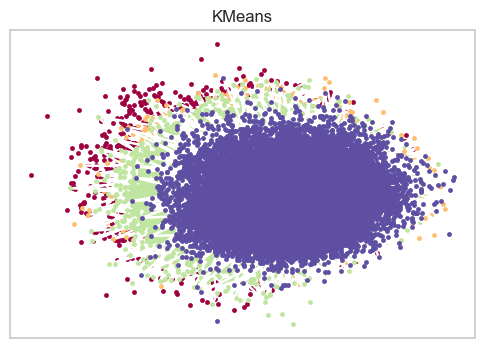

In [65]:
import numpy as np

# Initialize the plot with the specified dimensions.
fig = plt.figure(figsize=(6, 4))

# Colors uses a color map, which will produce an array of colors based on
# the number of labels there are. We use set(labels) to get the
# unique labels.
colors = plt.cm.Spectral(np.linspace(0, 1, len(set(labels))))

# Create a plot
ax = fig.add_subplot(1, 1, 1)

# For loop that plots the data points and centroids.
# k will range from 0-3, which will match the possible clusters that each
# data point is in.
for k, col in zip(range(optimal_k), colors):

    # Create a list of all data points, where the data points that are 
    # in the cluster (ex. cluster 0) are labeled as true, else they are
    # labeled as false.
    my_members = (labels == k)
    
    # Define the centroid, or cluster center.
    cluster_center = k_means_cluster_centers[k]
    
    # Plots the datapoints with color col.
    ax.plot(embeddings[my_members, 0], embeddings[my_members, 1], 'w', markerfacecolor=col, marker='.')
    
    # Plots the centroids with specified color, but with a darker outline
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)

# Title of the plot
ax.set_title('KMeans')

# Remove x-axis ticks
ax.set_xticks(())

# Remove y-axis ticks
ax.set_yticks(())

# Show the plot
plt.show()


In [66]:
# df = df.merge(
#     df_unique[['title', 'cluster', 'cluster_name']], 
#     on='title', 
#     how='left'
# )

print(metadata_unique)

       main_category                                              title  \
0         All Beauty  Howard LC0008 Leather Conditioner, 8-Ounce (4-...   
1         All Beauty  Yes to Tomatoes Detoxifying Charcoal Cleanser ...   
2         All Beauty   Eye Patch Black Adult with Tie Band (6 Per Pack)   
3         All Beauty  Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...   
4         All Beauty  Precision Plunger Bars for Cartridge Grips – 9...   
...              ...                                                ...   
112585    All Beauty  TOPREETY 24"120gr 3/4 Full Head clip in hair e...   
112586    All Beauty  Pets Playmate Pet Grooming Glove,Gentle Deshed...   
112587    All Beauty  [10Pack] Makeup Brushes Set Cosmetics Tools Ki...   
112588    All Beauty  Xcoser Pretty Party Anna Wig Hair Tails Hair S...   
112589    All Beauty  DVIO Men's Voyage Perfume, Spicy woody fragran...   

        average_rating  rating_number  \
0                  4.8             10   
1                

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# 1. Combine all text for each cluster into one "document"
cluster_docs = metadata_unique.groupby('cluster')['combined_text'].apply(lambda x: ' '.join(x))

# 2. Run TF-IDF to find the most "informative" words per cluster
vectorizer = TfidfVectorizer(stop_words='english', max_features=10)
tfidf_matrix = vectorizer.fit_transform(cluster_docs)

# 3. Extract the top 3 words for each cluster
feature_names = vectorizer.get_feature_names_out()
cluster_names = {}

for i in range(len(cluster_docs)):
    # Sort words by their TF-IDF score for this cluster
    scores = tfidf_matrix[i].toarray().flatten()
    top_indices = scores.argsort()[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    cluster_names[i] = " / ".join(top_words)

# 4. Map names back to your DataFrame
metadata_unique['cluster_name'] = metadata_unique['cluster'].map(cluster_names)

print(cluster_names)




{0: 'oz / pack / black / hair / women / natural / wig / nail / human / extensions', 1: 'nail / hair / women / natural / black / pack / extensions / oz / human / wig', 2: 'oz / hair / pack / natural / women / black / nail / human / extensions / wig', 3: 'hair / human / women / extensions / wig / black / natural / pack / oz / nail'}


In [69]:
custom_stops = ['beauty', 'hair', 'skin', 'natural', 'color', 'women', 'pack', 'human', 'black', 'nail']
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
all_stops = list(ENGLISH_STOP_WORDS) + custom_stops

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.25,   # If a word is in 2 or more clusters, kill it
    min_df=1, 
    max_features=15
)

tfidf_matrix = vectorizer.fit_transform(cluster_docs)

# 3. Extract the top 3 words for each cluster
feature_names = vectorizer.get_feature_names_out()
cluster_names = {}

for i in range(len(cluster_docs)):
    # Sort words by their TF-IDF score for this cluster
    scores = tfidf_matrix[i].toarray().flatten()
    top_indices = scores.argsort()[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    cluster_names[i] = " / ".join(top_words)

# 4. Map names back to your DataFrame
metadata_unique['cluster_name'] = metadata_unique['cluster'].map(cluster_names)

print(cluster_names)


{0: 'wefts / washer / vesunny / toyotress / stamper / runature / moresoo / jerry / irrigator / flatback', 1: 'fingernails / stamper / flatback / wefts / washer / vesunny / toyotress / runature / moresoo / jerry', 2: 'washer / irrigator / bathtub / wefts / vesunny / toyotress / stamper / runature / moresoo / jerry', 3: 'jerry / moresoo / vesunny / chignons / wefts / 13x4x1 / runature / toyotress / 7packs / washer'}


Bertopic    

In [71]:
%pip install bertopic

Note: you may need to restart the kernel to use updated packages.


In [90]:
from bertopic import BERTopic
from sklearn.cluster import KMeans
from bertopic.representation import OpenAI
import openai
import os
from dotenv import load_dotenv, find_dotenv

_ = load_dotenv(find_dotenv()) 
OPENAI_API_KEY  = os.getenv('OPENAI_API_KEY')
# 1. Prepare your custom sub-models
cluster_model = KMeans(n_clusters=optimal_k, random_state=42)

client = openai.OpenAI(api_key=OPENAI_API_KEY)
representation_model = OpenAI(client, model="gpt-4o-mini", delay_in_seconds=2)

# 2. Initialize BERTopic with everything at once
topic_model = BERTopic(
    hdbscan_model=cluster_model,      # Use KMeans for exactly 4 clusters
    representation_model=representation_model, # Use GPT for labeling
    embedding_model=model             # Your SentenceTransformer
)

# 3. Fit using your pre-calculated embeddings
topics, probs  = topic_model.fit_transform(
    metadata_unique['combined_text'].tolist(), 
    embeddings
)

# 4. View your new GPT-labeled 4 clusters
topic_info = topic_model.get_topic_info()
print(topic_info[['Topic', 'Count', 'Representation']])


metadata_unique['topic_id'] = topics

topic_info = topic_model.get_topic_info()
topic_names = dict(zip(topic_info.Topic, topic_info.Name))
metadata_unique['bertopic_category_name'] = metadata_unique['topic_id'].map(topic_names)



   Topic  Count                 Representation
0      0  58212    [Natural Skincare Products]
1      1  18803              [Human Hair Wigs]
2      2  17027            [Nail art products]
3      3  16524  [Hair accessories and braids]


The BERTopic Distribution (Uneven): This is likely more accurate. It means your dataset truly is 52% brushes/body products.The Original K-Means (Even): This is essentially "forcing" the data into 4 equal quadrants regardless of their actual category.

In [91]:
print(metadata_unique.head())

  main_category                                              title  \
0    All Beauty  Howard LC0008 Leather Conditioner, 8-Ounce (4-...   
1    All Beauty  Yes to Tomatoes Detoxifying Charcoal Cleanser ...   
2    All Beauty   Eye Patch Black Adult with Tie Band (6 Per Pack)   
3    All Beauty  Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...   
4    All Beauty  Precision Plunger Bars for Cartridge Grips – 9...   

   average_rating  rating_number  \
0             4.8             10   
1             4.5              3   
2             4.4             26   
3             3.1            102   
4             4.3              7   

                                            features  \
0                                                 []   
1                                                 []   
2                                                 []   
3                                                 []   
4  [Material: 304 Stainless Steel; Brass tip, Len...   

                         

In [95]:
metadata_unique['bertopic_category_name'] = (
    metadata_unique['bertopic_category_name']
    .str.replace(r'^\d+_', '', regex=True) # Remove the number and first underscore
    .str.replace('_', ' ')                 # Replace remaining underscores with spaces
    .str.title()                           # Capitalize each word
)

print(metadata_unique.head())


  main_category                                              title  \
0    All Beauty  Howard LC0008 Leather Conditioner, 8-Ounce (4-...   
1    All Beauty  Yes to Tomatoes Detoxifying Charcoal Cleanser ...   
2    All Beauty   Eye Patch Black Adult with Tie Band (6 Per Pack)   
3    All Beauty  Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...   
4    All Beauty  Precision Plunger Bars for Cartridge Grips – 9...   

   average_rating  rating_number  \
0             4.8             10   
1             4.5              3   
2             4.4             26   
3             3.1            102   
4             4.3              7   

                                            features  \
0                                                 []   
1                                                 []   
2                                                 []   
3                                                 []   
4  [Material: 304 Stainless Steel; Brass tip, Len...   

                         

In [ ]:
df_meta_full = pd.merge(
    metadata, 
    metadata_unique[['title', 'topic_id', 'bertopic_category_name']], 
    on='title', 
    how='left'
)


In [102]:
df_meta_full.head()


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,topic_id,bertopic_category_name
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,B01CUPMQZE,NaN,0,Natural Skincare Products
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",B076WQZGPM,NaN,0,Natural Skincare Products
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},B000B658RI,NaN,0,Natural Skincare Products
3,All Beauty,"Tattoo Eyebrow Stickers, Waterproof Eyebrow, 4...",3.1,102,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Cherioll,[],"{'Brand': 'Cherioll', 'Item Form': 'Powder', '...",B088FKY3VD,NaN,2,Nail Art Products
4,All Beauty,Precision Plunger Bars for Cartridge Grips – 9...,4.3,7,"[Material: 304 Stainless Steel; Brass tip, Len...",[The Precision Plunger Bars are designed to wo...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Precision,[],{'UPC': '644287689178'},B07NGFDN6G,NaN,0,Natural Skincare Products


In [101]:
# 1. Group by product name and count unique topic IDs
check = df_meta_full.groupby('title')['topic_id'].nunique()

# 2. Filter for any products that have more than 1 unique topic ID
inconsistent_products = check[check > 1]

if inconsistent_products.empty:
    print("✅ Success! All products with the same name share the same cluster.")
else:
    print(f"⚠️ Warning! {len(inconsistent_products)} products have multiple clusters:")
    print(inconsistent_products)


✅ Success! All products with the same name share the same cluster.


In [104]:
data = pd.read_json("datasets/All_Beauty.jsonl", lines=True)

In [114]:
df_meta_full = df_meta_full.rename(columns={'title': 'product_name'})
df_meta_full = df_meta_full.rename(columns={'images': 'original_images'})


df_reviews_final = pd.merge(
    data, 
    df_meta_full[['parent_asin', 'product_name', 'topic_id', 'bertopic_category_name', 'average_rating' ,'rating_number', "original_images" ]], 
    on='parent_asin', 
    how='left'
)

In [109]:
print(df_reviews_final.head(10))

   rating                                      title  \
0       5  Such a lovely scent but not overpowering.   
1       4     Works great but smells a little weird.   
2       5                                       Yes!   
3       1                          Synthetic feeling   
4       5                                         A+   
5       4                               Pretty Color   
6       5                                      Handy   
7       3                                        Meh   
8       5  Great for at home use and so easy to use!   
9       5                 Nice shampoo for the money   

                                                text  \
0  This spray is really nice. It smells really go...   
1  This product does what I need it to do, I just...   
2                          Smells good, feels great!   
3                                     Felt synthetic   
4                                            Love it   
5  The polish was quiet thick and did not apply

In [117]:
df_reviews_final.drop(columns=['user_id', 'timestamp' ])

df_reviews_final.to_csv('./datasets/final_reviews_with_categories.csv', index=False, encoding='utf-8-sig')

print("✅ File saved successfully!")

✅ File saved successfully!


In [115]:
df_reviews_final.columns

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase', 'product_name',
       'topic_id', 'bertopic_category_name', 'average_rating', 'rating_number',
       'original_images'],
      dtype='object')

In [116]:
print(df_reviews_final.iloc[0]['original_images'])

[{'thumb': 'https://m.media-amazon.com/images/I/41VQKmI9uKL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images/I/41VQKmI9uKL.jpg', 'variant': 'MAIN', 'hi_res': 'https://m.media-amazon.com/images/I/71twbtlDggL._SL1500_.jpg'}, {'thumb': 'https://m.media-amazon.com/images/I/51KFy1TxNYL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images/I/51KFy1TxNYL.jpg', 'variant': 'PT01', 'hi_res': 'https://m.media-amazon.com/images/I/A10jtK3Bm0L._SL1500_.jpg'}, {'thumb': 'https://m.media-amazon.com/images/I/41vw39v2nFL._SS40_.jpg', 'large': 'https://m.media-amazon.com/images/I/41vw39v2nFL.jpg', 'variant': 'PT02', 'hi_res': 'https://m.media-amazon.com/images/I/71vLmqaA6jL._SL1500_.jpg'}]
